In [281]:
import requests
import os
import json
import pandas as pd
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import create_react_agent
import chainlit as cl
from langchain_core.prompts import MessagesPlaceholder, ChatPromptTemplate
from langchain.agents.format_scratchpad.openai_tools import format_to_openai_tool_messages
from langchain.agents.output_parsers.openai_tools import OpenAIToolsAgentOutputParser
from langchain.agents import AgentExecutor
from langchain_core.messages import AIMessage, HumanMessage
from langchain_core.tools import tool
import os
from datetime import datetime
import plotly.express as px
# from langchain_experimental.sql import SQLDatabaseSequentialChain
from langchain_community.utilities.sql_database import SQLDatabase
# from langchain_experimental.sql import SQLDatabaseChain
from langchain.schema.runnable.config import RunnableConfig
from langchain_core.messages import HumanMessage
import chainlit as cl
os.environ['MPLCONFIGDIR'] = '/Users/george/.config/matplotlib'
import matplotlib.pyplot as plt
from langchain_core.prompts import MessagesPlaceholder, ChatPromptTemplate
from langchain_core.prompts import PromptTemplate
from typing_extensions import Annotated, TypedDict
from langgraph.prebuilt import create_react_agent
from langgraph_supervisor import create_supervisor
from langchain_openai import ChatOpenAI
from langchain_community.agent_toolkits import JsonToolkit, create_json_agent
from langchain_community.tools.json.tool import JsonSpec
from langchain_openai import OpenAI
from langchain.tools import Tool
import openai 
from langchain.tools import tool
from datetime import datetime
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import AnyMessage, add_messages
from langgraph.graph import StateGraph
from langgraph.graph import StateGraph, END
import subprocess


# from langchain.cache import InMemoryCache
# from langchain.globals import set_llm_cache
# set_llm_cache(InMemoryCache())

THINGSBOARD_URL = "http://localhost:8080"
USERNAME = "tenant@thingsboard.org"
PASSWORD = "tenant"
DASHBOARD_ID = "http://localhost:8080/tenants"

DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "thingsboard"
DB_USER = "thingsboard"
DB_PASSWORD = "postgres"


THINGSBOARD_HOST = "http://localhost:8080"
USERNAME = "tenant@thingsboard.org"
PASSWORD = "tenant"

load_dotenv()
openai_api_key = os.getenv('OPENAI_PROJECT_API_KEY')
open_weather_api = os.getenv('OPENWEATHERMAP_API_KEY')
# OPENAI_API_KEY = os.getenv('OPENAI_PROJECT_API_KEY')
# llm_model = "gpt-3.5-turbo"
client = openai.OpenAI(api_key=openai_api_key)
# client = ChatOpenAI(api_key=openai_api_key, model="gpt-4o")
model = ChatOpenAI(api_key=openai_api_key, model="gpt-4o")



# Load farm metadata 
with open("/Users/george/Documents/final_push/function-calling-for-sensors-at-the-edge/farm_model_small_v2.json", "r") as file:
    data = json.load(file)

# Authenticate with ThingsBoard
def authenticate():
    auth_url = f"{THINGSBOARD_URL}/api/auth/login"
    payload = {'username': USERNAME, 'password': PASSWORD}
    response = requests.post(auth_url, json=payload)
    response.raise_for_status()
    return response.json()['token']

jwt_token = authenticate()


# create tool
tools = [
    {
        "type": "function",
        "function": {
            "name": "get_farm_details",
            "description": "Return details about a specific farm field as a JSON object.",
            "parameters": {
                "type": "object",
                "properties": {
                    "a": {
                        "type": "integer",
                        "description": "The index of the field to retrieve details for (0-based).",
                    },
                },
                "required": ["a"],
            },
        },
    }
]

def get_farm_details(a: int) -> str:
    """Return Farm field details as a JSON string

    Args:
        a: Field Index
    """
    try:
        field_data = data['farm']['fields'][a]
        return json.dumps(field_data)
    except IndexError:
        return json.dumps({"error": f"Field index {a} is out of bounds."})
    except KeyError:
        return json.dumps({"error": "The 'farm' or 'fields' key was not found in the data."})
    except Exception as e:
        return json.dumps({"error": f"An error occurred: {e}"})
    


def sensor_extraction(query):
    """
    Processes a user's query to identify and extract relevant sensor IDs from specified farm fields.

    Args:
        query (str): The user's input query describing the desired sensor information.

    Returns:
        str or dict: A JSON-formatted string or dictionary containing the sensor IDs corresponding to the fields mentioned in the query.
    """
    messages = [
        {
            "role": "system",
            "content": (
                "You are a helpful assistant that identifies all relevant sensors mentioned in the user's request "
                "and returns them as a JSON array of their IDs, in this format: "
                '{"sensors": ["TEMP-0100", "TEMP-0700", ...]}. '
                "Match the user's field names to the following mappings:\n"
                "- F001: North Field\n"
                "- F002: Northeast Field\n"
                "- F003: East Field\n"
                "- F004: Southeast Field\n"
                "- F005: South Field\n"
                "- F006: Southwest Field\n"
                "- F007: West Field\n"
                "- F008: Northwest Field\n"
                "- F009: Central Field\n"
                "Extract sensors only from the fields mentioned. If no valid field is provided, return an empty JSON array.Do not hallucinate sensor device"
            ),
        },
        {"role": "user", "content": query},
    ]

    response = client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=messages,
        tools=tools,
        tool_choice="auto",
    )

    response_message = response.choices[0].message

    if hasattr(response_message, 'tool_calls') and response_message.tool_calls:
        tool_responses = []

        for tool_call in response_message.tool_calls:
            function_name = tool_call.function.name
            function_to_call = globals().get(function_name)
            if not function_to_call:
                continue  # Skip if the function is not defined

            function_args = json.loads(tool_call.function.arguments)
            function_response = function_to_call(**function_args)

            tool_responses.append({
                "tool_call_id": tool_call.id,
                "role": "tool",
                "name": function_name,
                "content": function_response,
            })

        # Append the assistant's message and all tool responses to the message history
        messages.append(response_message)
        messages.extend(tool_responses)

        # Send the updated message history back to the model
        second_response = client.chat.completions.create(
            model="gpt-3.5-turbo",
            messages=messages,
        )

        return second_response.choices[0].message.content
    else:
        # If no tool call, attempt to parse the response as JSON
        try:
            return json.loads(response_message.content)
        except (json.JSONDecodeError, TypeError):
            return response_message.content
        

# 2. Get device ID by name
def get_device_id_by_name(device_name, token):
    headers = {
        "Content-Type": "application/json",
        "X-Authorization": f"Bearer {token}"
    }
    url = f"{THINGSBOARD_URL}/api/tenant/devices?deviceName={device_name}"
    response = requests.get(url, headers=headers)
    response.raise_for_status()
    device = response.json()
    return device['id']['id'] if device else None

def get_device_keys(jwt_token, device_id):
    url = f"{THINGSBOARD_URL}/api/plugins/telemetry/DEVICE/{device_id}/keys/timeseries"
    headers = {
        "X-Authorization": f"Bearer {jwt_token}"
    }

    response = requests.get(url, headers=headers)
    if response.status_code == 200:
        return response.json()  # Returns a list of key names
    else:
        return {
            "error": f"Failed to fetch keys: {response.status_code}",
            "details": response.text
        }

# 2. Get device ID by name
def get_device_id_by_name(device_name, token):
    headers = {
        "Content-Type": "application/json",
        "X-Authorization": f"Bearer {token}"
    }
    url = f"{THINGSBOARD_URL}/api/tenant/devices?deviceName={device_name}"
    response = requests.get(url, headers=headers)
    response.raise_for_status()
    device = response.json()
    return device['id']['id'] if device else None


def get_device_keys(jwt_token, device_id):
    url = f"{THINGSBOARD_URL}/api/plugins/telemetry/DEVICE/{device_id}/keys/timeseries"
    headers = {
        "X-Authorization": f"Bearer {jwt_token}"
    }

    response = requests.get(url, headers=headers)
    if response.status_code == 200:
        return response.json()  # Returns a list of key names
    else:
        return {
            "error": f"Failed to fetch keys: {response.status_code}",
            "details": response.text
        }



def weather_search(query: str) -> dict:
    """
    Search for weather data using the OpenWeather API.
    """
    api_key = open_weather_api
    if not api_key:
        return {"error": "OpenWeatherMap API key not found in environment variables."}

    base_url = "https://api.openweathermap.org/data/2.5/weather"
    params = {
        'q': query,
        'appid': api_key,
        'units': 'metric'  # Use 'imperial' for Fahrenheit
    }

    response = requests.get(base_url, params=params)
    if response.status_code == 200:
        return response.json()
    else:
        return {
            "error": f"Failed to fetch weather data: {response.status_code}",
            "details": response.json()
        }


def get_weather_forecast(city):
    """
    Fetch a 5-day weather forecast (in 3-hour intervals) for a given city
    using the OpenWeatherMap API.

    Args:
        city (str): The name of the city to retrieve the forecast for.
        api_key (str): Your OpenWeatherMap API key.

    Returns:
        list[dict]: A list of dictionaries containing datetime, weather description,
                    and temperature for each forecast entry.
                    Returns an empty list if the API request fails.
    """
    url = "http://api.openweathermap.org/data/2.5/forecast"
    params = {
        'q': city,
        'appid': open_weather_api,
        'units': 'metric',
        'cnt': 10  # Number of forecast entries
    }

    response = requests.get(url, params=params)
    
    if response.status_code == 200:
        data = response.json()
        forecast = data['list']

        result = []
        for entry in forecast:
            dt = datetime.utcfromtimestamp(entry['dt'])
            date_time = dt.strftime('%Y-%m-%d %H:%M:%S')
            temp = entry['main']['temp']
            weather = entry['weather'][0]['description']
            result.append({
                'datetime': date_time,
                'weather': weather,
                'temperature_celsius': temp
            })
        return result
    else:
        return []
    
# Use pass the state to receive runtime arguments
def run_alert_script():
    """
    Executes the external Python script 'my_script.py' using subprocess.

    Args:
        state (dict): Input state dictionary (unused in this function, but required for LangGraph compatibility).

    Returns:
        dict: A dictionary containing:
            - 'stdout': The standard output from the script, if it runs successfully.
            - 'stderr': The standard error from the script, if any.
            - 'error': The error message if the script fails to execute properly.
    """

    try:
        result = subprocess.run(
            ["python", "alert.py"],
            capture_output=True,
            text=True,
            check=True
        )
        return {
            "stdout": result.stdout,
            "stderr": result.stderr
        }
    except subprocess.CalledProcessError as e:
        return {
            "error": e.stderr
        }

# class State(TypedDict):
#     messages: Annotated[list[AnyMessage], add_messages]


# Similarly, create the sensor extraction agent with a name
sensor_extraction_agent = create_react_agent(
    model=model,
    tools=[sensor_extraction],
    prompt="You are an expert in extracting sensor data from user queries.",
    name="sensor_extraction_agent"
)

# Now create the agent using LangGraph's create_react_agent
weather_agent = create_react_agent(
    model,
    tools=[get_weather_forecast, weather_search],
    prompt="You are a weather assistant, if not city is provide use Kigali as the default city. Use the `weather_search` tool to answer weather-related queries and `get_weather_forecast` to answer weather-forecast related queries",
    name="weather_agent"
)

# Now create Alert Agent
alert_agent = create_react_agent(
    model,
    tools=[run_alert_script],
    prompt="You are a alert assistant, you create alert by running the `run_alert_script` function",
    name="alert_agent"

) 

# sensor_team = create_supervisor(
#     agents = [sensor_retrival_agent, sensor_visualization_agent], 
#     model = model, 
#     prompt=(
        
#     )
# )

# Create the supervisor workflow
top_supervisor = create_supervisor(
    agents=[weather_agent, alert_agent],
    model=model,
    prompt=(
        "You are a Farm Supervisor Agent. Your responsibilities include overseeing tasks related to sensor data retrieval and weather information. "
        "Delegate sensor-related queries to the sensor_extraction_agent, weather-related queries to the weather_agent and alert related queries to the alert_agent"

    )
).compile(name="SCADAgric")







# @cl.on_chat_start
# async def main():
#     # await cl.Message(content="Hello World").send()
#     pass


# @cl.set_starters
# async def set_starters():
#     return [
#         cl.Starter(
#             label="Farm Summary",
#             message="What all sensor data in all fields?",
#             icon="/public/idea.svg",
#         ),
#         cl.Starter(
#             label="Realtime Information",
#             message="Give me realtime data.",
#             icon="/public/write.svg",
#         ),
#         cl.Starter(
#             label="How control a pump?",
#             message="Control the actuactor.",
#             icon="/public/learn.svg",
#         ),
#         cl.Starter(
#             label="Get Farm Alert",
#             message="Write a Chainlit hello world app.",
#             icon="/public/terminal.svg",
#         ),
#         cl.Starter(
#             label="Get Farm Weather",
#             message="What is the weather in  Nyagatare District, Eastern Province, Rwanda.",
#             icon="/public/cloudy.png",
#         ),
#     ]



# @cl.on_message
# async def on_message(message: cl.Message):
#     config = {"configurable": {"thread_id": cl.context.session.id}}
#     cb = cl.LangchainCallbackHandler()
#     final_answer = cl.Message(content="")

#     async for output in top_supervisor.astream(
#         {"messages": [HumanMessage(content=message.content)]},
#         config=RunnableConfig(callbacks=[cb], **config)
#     ):
#         print(f"Supervisor Output Step: {output}")
#         if isinstance(output, dict) and "supervisor" in output and "messages" in output["supervisor"] and output["supervisor"]["messages"]:
#             last_supervisor_message = output["supervisor"]["messages"][-1]
#             if isinstance(last_supervisor_message, AIMessage):
#                 await final_answer.stream_token(last_supervisor_message.content)
#         elif isinstance(output, dict) and "messages" in output and output["messages"]:
#             last_message = output["messages"][-1]
#             if isinstance(last_message, AIMessage):
#                 await final_answer.stream_token(last_message.content)

#     await final_answer.send()

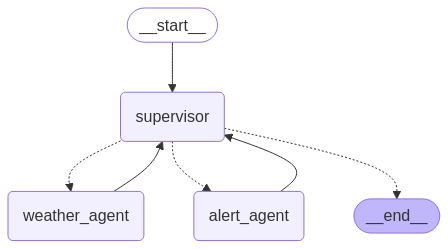

In [283]:
# Compile the graph
# graph = top_supervisor.compile()
# View
display(Image(top_supervisor.get_graph().draw_mermaid_png()))

In [ ]:
top_supervisor.invoke({"messages": [], "chat_mode": "weather_query"})

In [287]:
from langgraph.graph import StateGraph, END
from langchain_core.runnables import RunnableLambda

state = {
    "user_query": str,
    "sensor_name": str,
    "sensor_metadata": str,
    "sensor_plot_path": str,
    "action": str,  # either "visualize" or "retrieve"
}


# ---- Tools or agents ----
def sensor_extraction_node(state):
    query = state["user_query"]
    # Fake extractor output
    return {
        **state,
        "sensor_name": "TEMP-0500",
        "action": "visualize" if "plot" in query.lower() else "retrieve"
    }

def sensor_retrival_agent(state):
    # Fake retrieval
    return {
        **state,
        "sensor_metadata": f"Sensor {state['sensor_name']} is a temperature sensor installed in North Field"
    }

def sensor_visualization_agent(state):
    # Fake visualization
    return {
        **state,
        "sensor_plot_path": f"/plots/{state['sensor_name']}_latest.png"
    }

# ---- Router for next step ----
def sensor_team_router(state):
    if state.get("action") == "visualize":
        return "sensor_visualization"
    return "sensor_retrival"

# ---- LangGraph Build ----
builder = StateGraph(dict)
builder.add_node("sensor_extraction", RunnableLambda(sensor_extraction_node))
builder.add_node("sensor_retrival", RunnableLambda(sensor_retrival_agent))
builder.add_node("sensor_visualization", RunnableLambda(sensor_visualization_agent))

# Route after extraction
builder.add_conditional_edges(
    "sensor_extraction",
    sensor_team_router,
    {
        "sensor_visualization": "sensor_visualization",
        "sensor_retrival": "sensor_retrival"
    }
)

# End both branches
builder.add_edge("sensor_visualization", END)
builder.add_edge("sensor_retrival", END)
builder.set_entry_point("sensor_extraction")

# Finalize
graph = builder.compile()


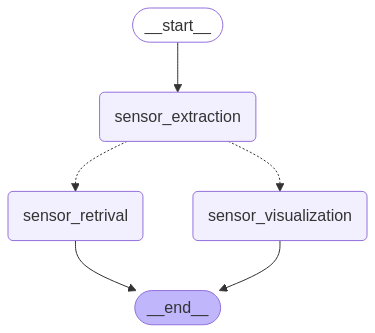

In [288]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [289]:
# Simulate a user query
input_state = {
    "user_query": "Plot the latest temperature data from North Field"
}

result = graph.invoke(input_state)
print(result)


{'user_query': 'Plot the latest temperature data from North Field', 'sensor_name': 'TEMP-0500', 'action': 'visualize', 'sensor_plot_path': '/plots/TEMP-0500_latest.png'}
